Bus Schedule Creator


Enter the origin:  Munich
Enter the destination:  Salzburg
Enter the travel time from Munich to Salzburg (in minutes):  180


Terminal time at Salzburg: 27 minutes


Enter the headway (time interval between successive vehicles in minutes):  30
Enter the departure date (YYYY-MM-DD):  0


Invalid date format. Please use YYYY-MM-DD.


Enter the departure date (YYYY-MM-DD):  2026-05-04
Enter the start time for the schedule (HH:MM):  06:00
Enter the end time for the schedule (HH:MM):  02:00



Number of vehicles needed: 14
Initial cycle time: 414 minutes
Adjusted cycle time: 420 minutes
Schedule efficiency: 98.57%


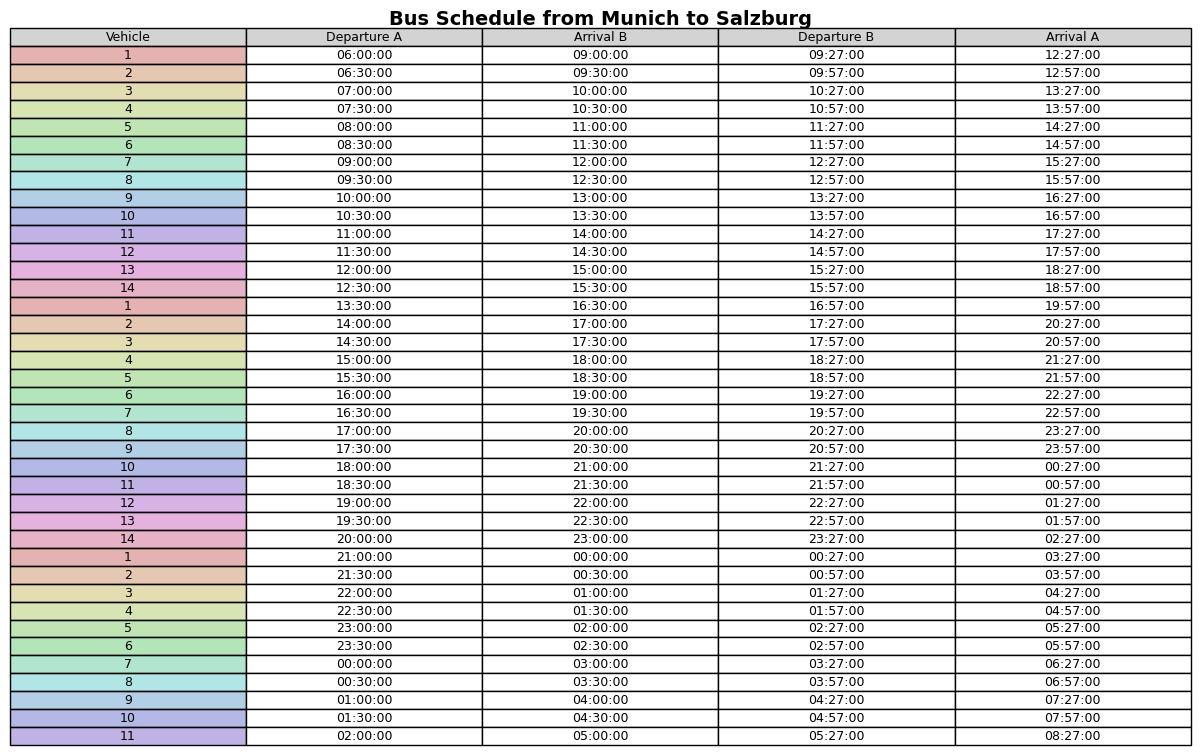

Schedule exported to schedule_Munich_Salzburg_2026-05-04.csv


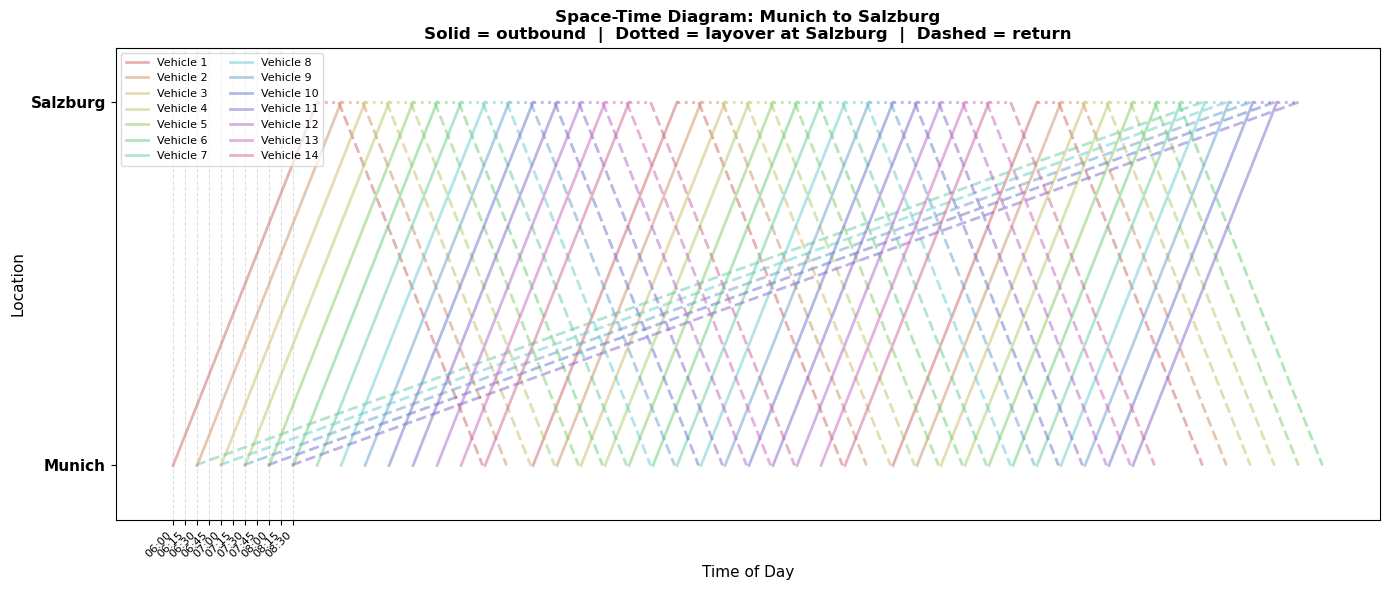

In [1]:
import math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt  # Importing Matplotlib for plotting
import matplotlib.colors as mcolors
import colorsys
def get_time_input(prompt):
    """To ensure the time input is in HH:MM format."""
    while True:
        time_str = input(prompt)
        try:
            return datetime.strptime(time_str, '%H:%M').time()
        except ValueError:
            print("Invalid time format. Please use HH:MM.")
def get_date_input(prompt):
    """To ensure the date input is in YYYY-MM-DD format."""
    while True:
        date_str = input(prompt)
        try:
            return datetime.strptime(date_str, '%Y-%m-%d').date()
        except ValueError:
            print("Invalid date format. Please use YYYY-MM-DD.")
            
def vehicle_identification(num_colors):
    colors=[]
    for i in range(num_colors):
        hue = i/num_colors
        saturation = 0.5
        value = 0.8
        rgb = colorsys.hsv_to_rgb(hue,saturation,value)
        color =mcolors.to_rgba(rgb,alpha=0.5)
        colors.append(color)
    return colors
    
def main():
    print("Bus Schedule Creator")
    origin = input("Enter the origin: ")
    destination = input("Enter the destination: ")
    travel_time = int(input(f"Enter the travel time from {origin} to {destination} (in minutes): "))
    
    terminal_time = int(0.15 * travel_time)
    print(f"Terminal time at {destination}: {terminal_time} minutes")
    
    headway = int(input("Enter the headway (time interval between successive vehicles in minutes): "))
    departure_date = get_date_input("Enter the departure date (YYYY-MM-DD): ")
    start_time = get_time_input("Enter the start time for the schedule (HH:MM): ")
    end_time = get_time_input("Enter the end time for the schedule (HH:MM): ")
    current_departure_a = datetime.combine(departure_date, start_time)
    end_datetime = datetime.combine(departure_date, end_time)
    if end_datetime < current_departure_a:
        end_datetime += timedelta(days=1)
    total_cycle_time = 2 * (travel_time + terminal_time)
    num_vehicles = math.ceil(total_cycle_time / headway)
    adjusted_cycle_time = num_vehicles * headway
    print(f"\nNumber of vehicles needed: {num_vehicles}")
    print(f"Initial cycle time: {total_cycle_time} minutes")
    print(f"Adjusted cycle time: {adjusted_cycle_time} minutes")
    
    efficiency = (total_cycle_time / adjusted_cycle_time) * 100
    print(f"Schedule efficiency: {efficiency:.2f}%")
    vehicle_colors = vehicle_identification(num_vehicles)
    schedule_data = []
    vehicle_index = 0
    while current_departure_a <= end_datetime:
        if vehicle_index < num_vehicles:
            arrival_b = current_departure_a + timedelta(minutes=travel_time)
            departure_b = arrival_b + timedelta(minutes=terminal_time)
            arrival_a = departure_b + timedelta(minutes=travel_time)
            schedule_data.append([
                vehicle_index + 1,
                current_departure_a.time(),
                arrival_b.time(),
                departure_b.time(),
                arrival_a.time()
            ])
            vehicle_index += 1
        else:
            vehicle_index = 0
        
        current_departure_a += timedelta(minutes=headway)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis('tight')
    ax.axis('off')
    table_data = [["Vehicle","Departure A", "Arrival B", "Departure B", "Arrival A"]] + schedule_data
    cell_colors = [['lightgray'] * 5]  # Header row color
    for row in schedule_data:
        row_colors = [vehicle_colors[row[0] - 1]] + ['white'] * 4
        cell_colors.append(row_colors)
    title_text = f"Bus Schedule from {origin} to {destination}"
    plt.suptitle(title_text, fontsize=14, fontweight='bold', ha='center', y=0.95)
    table = ax.table(cellText=table_data, cellLoc='center', loc='center', cellColours=cell_colors)
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.2)
    plt.tight_layout()
    plt.show()

    export_csv(schedule_data, origin, destination, departure_date)
    plot_space_time_diagram(
        schedule_data, origin, destination,
        vehicle_colors, travel_time, terminal_time
    )

def export_csv(schedule_data, origin, destination, departure_date):
    """Export the schedule to a CSV file."""
    import csv
    filename = f"schedule_{origin}_{destination}_{departure_date}.csv"
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Vehicle", "Departure A", "Arrival B", "Departure B", "Arrival A"])
        for row in schedule_data:
            writer.writerow([row[0]] + [t.strftime('%H:%M') for t in row[1:]])
    print(f"Schedule exported to {filename}")
    return filename


def plot_space_time_diagram(schedule_data, origin, destination, vehicle_colors, travel_time, terminal_time):
    """
    Plot a Space-Time Diagram for the bus schedule.

    X-axis: time of day (minutes from start of schedule)
    Y-axis: spatial position (0 = origin A, 1 = destination B)

    Each vehicle trip is drawn as a series of connected line segments:
      - Outbound leg   : origin A -> destination B  (diagonal, upward)
      - Layover at B   : horizontal segment at B    (flat, recovery time)
      - Return leg     : destination B -> origin A  (diagonal, downward)

    Vehicles are colour-coded consistently with the schedule table.
    """
    fig, ax = plt.subplots(figsize=(14, 6))

    # Determine the earliest departure to use as time axis zero reference
    reference_time = datetime.combine(
        datetime.today().date(), schedule_data[0][1]
    )

    def to_minutes(t):
        """Convert a time object to minutes elapsed since reference_time."""
        dt = datetime.combine(datetime.today().date(), t)
        delta = dt - reference_time
        # Handle overnight schedules where dt < reference_time
        if delta.total_seconds() < 0:
            delta += timedelta(days=1)
        return delta.total_seconds() / 60

    # Group trips by vehicle number so each vehicle gets one continuous trace
    from collections import defaultdict
    vehicle_trips = defaultdict(list)
    for row in schedule_data:
        vehicle_trips[row[0]].append(row)

    for vehicle_num, trips in vehicle_trips.items():
        color = vehicle_colors[vehicle_num - 1]
        first_trip = True
        for trip in trips:
            _, dep_a, arr_b, dep_b, arr_a = trip

            t_dep_a = to_minutes(dep_a)
            t_arr_b = to_minutes(arr_b)
            t_dep_b = to_minutes(dep_b)
            t_arr_a = to_minutes(arr_a)

            # Outbound: A (y=0) -> B (y=1)
            ax.plot(
                [t_dep_a, t_arr_b], [0, 1],
                color=color, linewidth=2,
                label=f"Vehicle {vehicle_num}" if first_trip else "_nolegend_"
            )
            # Layover at B: horizontal flat line (recovery/terminal time)
            ax.plot(
                [t_arr_b, t_dep_b], [1, 1],
                color=color, linewidth=2, linestyle='dotted'
            )
            # Return: B (y=1) -> A (y=0)
            ax.plot(
                [t_dep_b, t_arr_a], [1, 0],
                color=color, linewidth=2, linestyle='dashed'
            )
            first_trip = False

    # ── Axis formatting ──────────────────────────────────────────────────────
    # Build readable time labels on the x-axis every 15 minutes
    max_minutes = to_minutes(schedule_data[-1][4])  # last arrival back at A
    tick_interval = 15
    tick_positions = list(range(0, int(max_minutes) + tick_interval, tick_interval))
    tick_labels = [
        (reference_time + timedelta(minutes=m)).strftime('%H:%M')
        for m in tick_positions
    ]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)

    # Y-axis: only two spatial stops
    ax.set_yticks([0, 1])
    ax.set_yticklabels([origin, destination], fontsize=11, fontweight='bold')
    ax.set_ylim(-0.15, 1.15)

    # ── Grid, labels, legend ─────────────────────────────────────────────────
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_xlabel("Time of Day", fontsize=11)
    ax.set_ylabel("Location", fontsize=11)
    ax.set_title(
        f"Space-Time Diagram: {origin} to {destination}\n"
        f"Solid = outbound  |  Dotted = layover at {destination}  |  Dashed = return",
        fontsize=12, fontweight='bold'
    )
    ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.7)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


  Bus Schedule Creator



Enter the origin:  Ostbahnof
Enter the destination:  Haubpbahnof
Enter the one-way route distance Ostbahnof to Haubpbahnof (km):  8
Enter the travel time Ostbahnof to Haubpbahnof (minutes):  30



  Default terminal time (15% of travel): 4 min


  Override terminal time? [y/n]:  y
  Terminal time (minutes, min 0):  10


  Terminal time: 10 min


...


Select bus type [1-5]:  1



  Selected      : Diesel
  Default range : 600 km
  Default service time : 10 min


  Override defaults? [y/n]:  n



── Schedule Summary ─────────────────────────────────────────────
  Vehicles required      : 6
  Theoretical cycle time : 80 min
  Adjusted cycle time    : 90 min
  Schedule efficiency    : 88.9%

── Service / Energy Events ──────────────────────────────────────
  No service stops needed within the scheduled window.

── Generating outputs ───────────────────────────────────────────


C:\Users\anjy_\AppData\Local\Temp\ipykernel_17688\1888535606.py:229: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


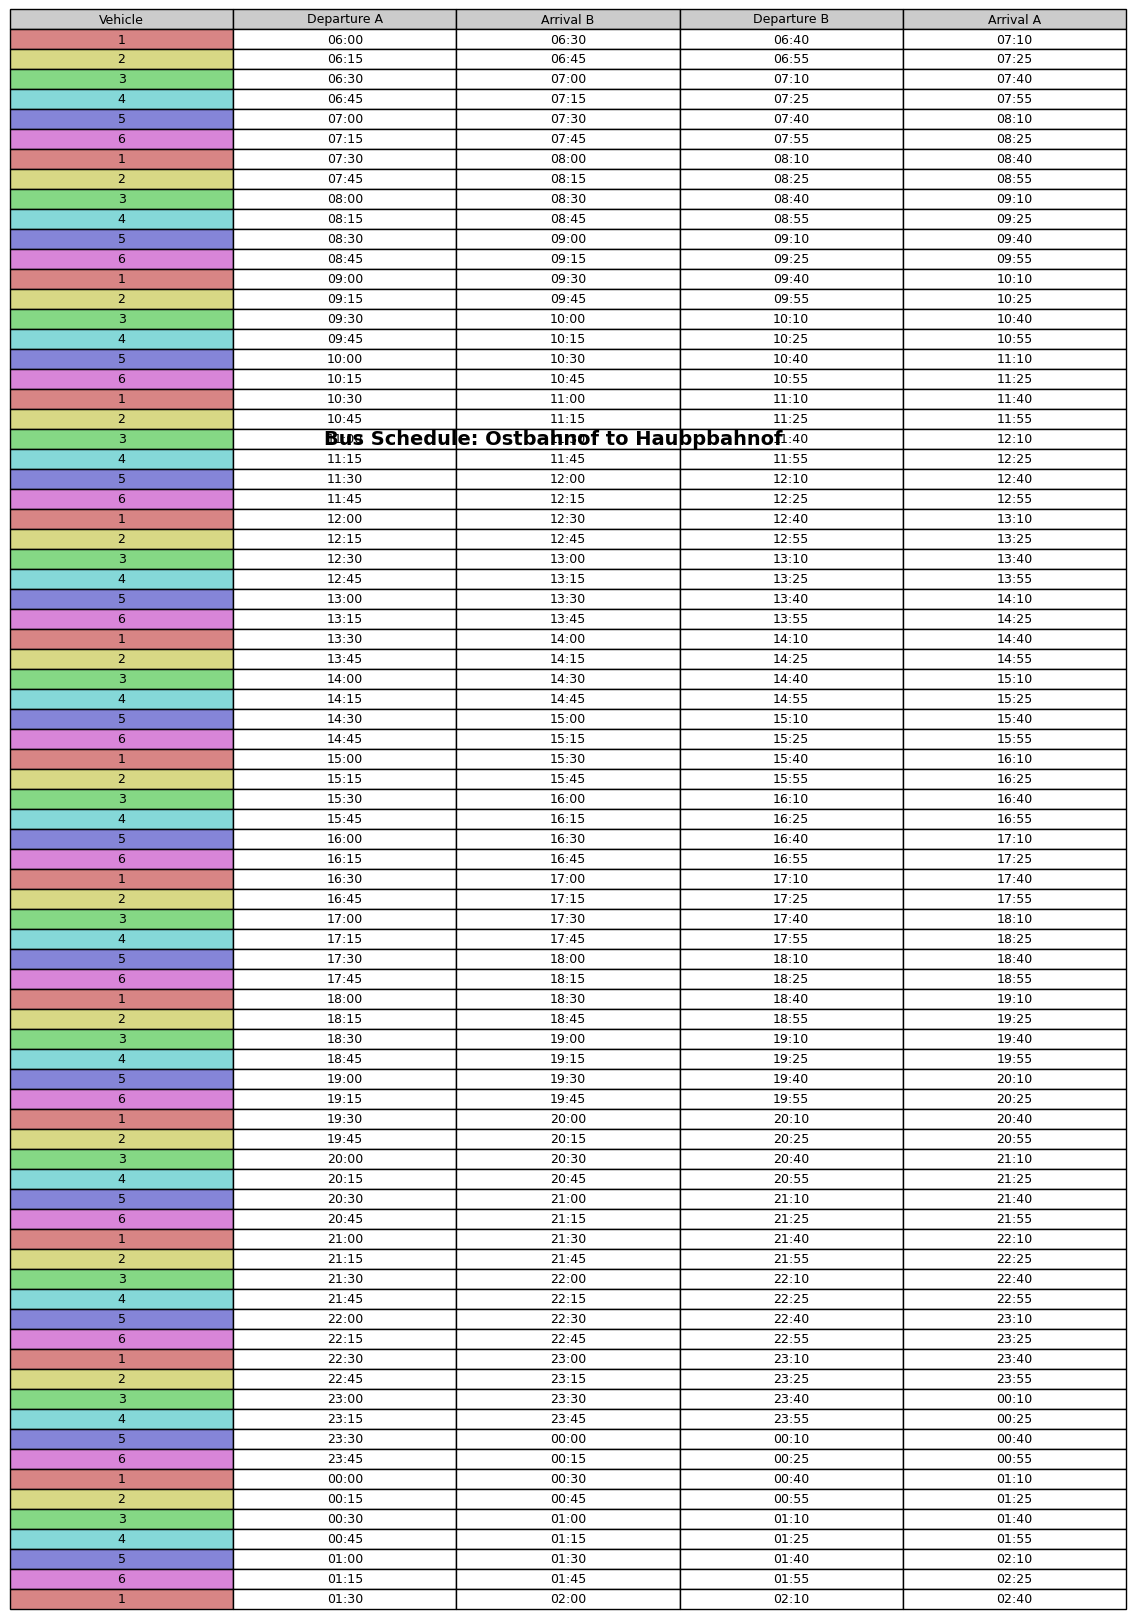

  Exported to: schedule_Ostbahnof_Haubpbahnof_2026-04-25.csv


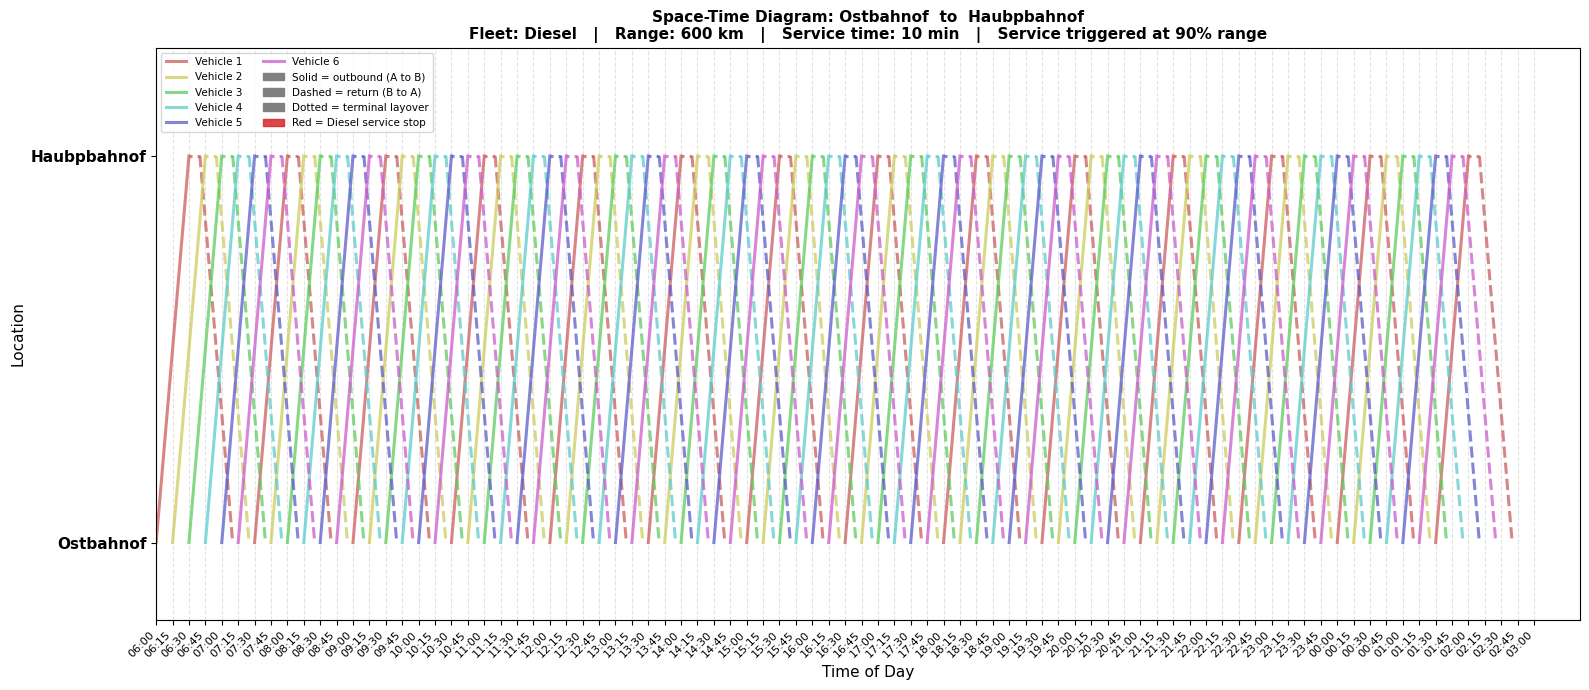

  No service events within the scheduled window.


In [3]:
import csv
import math
import colorsys
from collections import defaultdict
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


# ─────────────────────────────────────────────────────────────────────────────
# Bus type catalogue
# Each entry defines the energy type, usable range (km), and service duration.
# Service duration is the time (minutes) the vehicle is out of service at the
# terminal for refuelling or recharging.  These are representative defaults;
# operators are prompted to override them.
# ─────────────────────────────────────────────────────────────────────────────
BUS_CATALOGUE = {
    '1': {
        'name':        'Diesel',
        'energy':      'Diesel',
        'range_km':    600,
        'service_min': 10,
        'description': 'Conventional diesel bus — long range, quick refuel',
    },
    '2': {
        'name':        'Electric (Battery)',
        'energy':      'Electric',
        'range_km':    250,
        'service_min': 45,
        'description': 'Battery-electric bus — zero emissions, longer charge stop',
    },
    '3': {
        'name':        'Hydrogen (FCEV)',
        'energy':      'Hydrogen',
        'range_km':    400,
        'service_min': 8,
        'description': 'Fuel-cell electric bus — fast refuel, longer range than BEV',
    },
    '4': {
        'name':        'Hybrid (Diesel-Electric)',
        'energy':      'Hybrid',
        'range_km':    450,
        'service_min': 12,
        'description': 'Diesel-electric hybrid — moderate range, reduced emissions',
    },
    '5': {
        'name':        'CNG (Compressed Natural Gas)',
        'energy':      'CNG',
        'range_km':    350,
        'service_min': 10,
        'description': 'CNG bus — cleaner than diesel, purpose-built fuelling needed',
    },
}

# Colour used to mark downtime segments on the space-time diagram
DOWNTIME_COLOR = '#d62728'
DOWNTIME_ALPHA = 0.85


# ─────────────────────────────────────────────────────────────────────────────
# Input helpers
# ─────────────────────────────────────────────────────────────────────────────

def get_time_input(prompt):
    """Validate and return a time object from HH:MM input."""
    while True:
        time_str = input(prompt)
        try:
            return datetime.strptime(time_str, '%H:%M').time()
        except ValueError:
            print("  Invalid format — please use HH:MM (e.g. 06:30).")


def get_date_input(prompt):
    """Validate and return a date object from YYYY-MM-DD input."""
    while True:
        date_str = input(prompt)
        try:
            return datetime.strptime(date_str, '%Y-%m-%d').date()
        except ValueError:
            print("  Invalid format — please use YYYY-MM-DD (e.g. 2024-06-01).")


def get_positive_int(prompt, min_val=1):
    """Validate and return an integer >= min_val."""
    while True:
        try:
            val = int(input(prompt))
            if val >= min_val:
                return val
            print(f"  Value must be at least {min_val}.")
        except ValueError:
            print("  Please enter a whole number.")


def get_bus_config(route_km):
    """
    Prompt the operator to choose a bus type and optionally override the
    default range and service time.

    Returns a config dict with keys: name, energy, range_km, service_min.
    """
    print("\n── Bus Fleet Configuration ──────────────────────────────────────")
    for key, cfg in BUS_CATALOGUE.items():
        print(f"  {key}. {cfg['name']:30s}  {cfg['description']}")

    while True:
        choice = input("\nSelect bus type [1-5]: ").strip()
        if choice in BUS_CATALOGUE:
            bus = dict(BUS_CATALOGUE[choice])
            break
        print("  Please enter a number between 1 and 5.")

    print(f"\n  Selected      : {bus['name']}")
    print(f"  Default range : {bus['range_km']} km")
    print(f"  Default service time : {bus['service_min']} min")

    if input("  Override defaults? [y/n]: ").strip().lower() == 'y':
        bus['range_km']   = get_positive_int("  Vehicle range (km, min 1): ", min_val=1)
        bus['service_min'] = get_positive_int("  Service / charge time (min, min 1): ", min_val=1)

    if route_km > bus['range_km']:
        print(
            f"\n  WARNING: one-way route distance ({route_km} km) exceeds the "
            f"vehicle range ({bus['range_km']} km). Consider a longer-range vehicle."
        )

    return bus


# ─────────────────────────────────────────────────────────────────────────────
# Colour generator
# ─────────────────────────────────────────────────────────────────────────────

def generate_vehicle_colors(num_colors):
    """Return a list of RGBA colours, one per vehicle, spaced evenly in HSV."""
    colors = []
    for i in range(num_colors):
        rgb   = colorsys.hsv_to_rgb(i / num_colors, 0.55, 0.80)
        color = mcolors.to_rgba(rgb, alpha=0.75)
        colors.append(color)
    return colors


# ─────────────────────────────────────────────────────────────────────────────
# Downtime computation
# ─────────────────────────────────────────────────────────────────────────────

def compute_downtime_events(schedule_data, bus_cfg, route_km, terminal_time):
    """
    Walk each vehicle's trips chronologically and fire a service event every
    time the accumulated distance reaches 90% of the vehicle range.

    Service always takes place at terminal B (arrival end of outbound leg).
    The event records whether it fits within the normal layover window or
    causes an operational delay.

    Returns a list of dicts with keys:
        vehicle, start (datetime), end (datetime),
        trigger_km, fits (bool), delay_min (int).
    """
    range_km      = bus_cfg['range_km']
    service_min   = bus_cfg['service_min']
    threshold_km  = range_km * 0.90
    today         = datetime.today().date()

    vehicle_trips = defaultdict(list)
    for row in schedule_data:
        vehicle_trips[row[0]].append({
            'arr_b': datetime.combine(today, row[2]),
        })

    for veh in vehicle_trips:
        vehicle_trips[veh].sort(key=lambda x: x['arr_b'])

    events = []
    for veh_num, trips in vehicle_trips.items():
        odometer = 0.0
        for trip in trips:
            odometer += route_km * 2
            if odometer >= threshold_km:
                svc_start  = trip['arr_b']
                svc_end    = svc_start + timedelta(minutes=service_min)
                fits       = service_min <= terminal_time
                delay_min  = max(0, service_min - terminal_time)
                events.append({
                    'vehicle':    veh_num,
                    'start':      svc_start,
                    'end':        svc_end,
                    'trigger_km': odometer,
                    'fits':       fits,
                    'delay_min':  delay_min,
                })
                odometer = 0

    return events


# ─────────────────────────────────────────────────────────────────────────────
# Schedule table
# ─────────────────────────────────────────────────────────────────────────────

def plot_schedule_table(schedule_data, origin, destination, vehicle_colors):
    """Colour-coded schedule table."""
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.axis('tight')
    ax.axis('off')

    table_data  = [["Vehicle", "Departure A", "Arrival B", "Departure B", "Arrival A"]]
    cell_colors = [['#cccccc'] * 5]

    for row in schedule_data:
        table_data.append([row[0]] + [t.strftime('%H:%M') for t in row[1:]])
        cell_colors.append([vehicle_colors[row[0] - 1]] + ['white'] * 4)

    plt.suptitle(
        f"Bus Schedule: {origin} to {destination}",
        fontsize=14, fontweight='bold', ha='center', y=0.97
    )
    table = ax.table(
        cellText=table_data, cellLoc='center',
        loc='center', cellColours=cell_colors
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.2)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CSV export
# ─────────────────────────────────────────────────────────────────────────────

def export_csv(schedule_data, origin, destination, departure_date,
               downtime_events, bus_cfg):
    """Export schedule, bus config, and downtime events to a single CSV."""
    filename = f"schedule_{origin}_{destination}_{departure_date}.csv"
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)

        writer.writerow(["TRIP SCHEDULE"])
        writer.writerow(["Vehicle", "Departure A", "Arrival B", "Departure B", "Arrival A"])
        for row in schedule_data:
            writer.writerow([row[0]] + [t.strftime('%H:%M') for t in row[1:]])

        writer.writerow([])
        writer.writerow(["BUS CONFIGURATION"])
        writer.writerow(["Type", "Energy", "Range (km)", "Service Time (min)"])
        writer.writerow([bus_cfg['name'], bus_cfg['energy'],
                         bus_cfg['range_km'], bus_cfg['service_min']])

        writer.writerow([])
        writer.writerow(["DOWNTIME / SERVICE EVENTS"])
        writer.writerow([
            "Vehicle", "Service Start", "Service End",
            "Odometer at Trigger (km)", "Fits in Layover", "Extra Delay (min)"
        ])
        for evt in downtime_events:
            writer.writerow([
                evt['vehicle'],
                evt['start'].strftime('%H:%M'),
                evt['end'].strftime('%H:%M'),
                evt['trigger_km'],
                "Yes" if evt['fits'] else "No",
                evt['delay_min'] if evt['delay_min'] > 0 else "None",
            ])

    print(f"  Exported to: {filename}")
    return filename


# ─────────────────────────────────────────────────────────────────────────────
# Space-time diagram with downtime overlay
# ─────────────────────────────────────────────────────────────────────────────

def plot_space_time_diagram(
    schedule_data, origin, destination,
    vehicle_colors, travel_time, terminal_time,
    downtime_events, bus_cfg
):
    """
    Space-time diagram.

    Solid diagonal up    = outbound leg (A to B)
    Dashed diagonal down = return leg   (B to A)
    Dotted horizontal    = terminal layover at B
    Red filled band      = service / charging downtime at B
    """
    fig, ax = plt.subplots(figsize=(16, 7))

    today          = datetime.today().date()
    reference_time = datetime.combine(today, schedule_data[0][1])

    def to_min(t):
        dt    = datetime.combine(today, t)
        delta = dt - reference_time
        if delta.total_seconds() < 0:
            delta += timedelta(days=1)
        return delta.total_seconds() / 60

    def dt_to_min(dt):
        delta = dt - reference_time
        if delta.total_seconds() < 0:
            delta += timedelta(days=1)
        return delta.total_seconds() / 60

    # ── Vehicle traces ────────────────────────────────────────────────────────
    vehicle_trips = defaultdict(list)
    for row in schedule_data:
        vehicle_trips[row[0]].append(row)

    for veh_num, trips in vehicle_trips.items():
        color      = vehicle_colors[veh_num - 1]
        first_trip = True
        for trip in trips:
            _, dep_a, arr_b, dep_b, arr_a = trip
            t_dep_a = to_min(dep_a)
            t_arr_b = to_min(arr_b)
            t_dep_b = to_min(dep_b)
            t_arr_a = to_min(arr_a)

            label = f"Vehicle {veh_num}" if first_trip else "_nolegend_"
            ax.plot([t_dep_a, t_arr_b], [0, 1],
                    color=color, linewidth=2.2, label=label)
            ax.plot([t_arr_b, t_dep_b], [1, 1],
                    color=color, linewidth=2.2, linestyle='dotted')
            ax.plot([t_dep_b, t_arr_a], [1, 0],
                    color=color, linewidth=2.2, linestyle='dashed')
            first_trip = False

    # ── Downtime overlay ──────────────────────────────────────────────────────
    downtime_label_added = False
    for evt in downtime_events:
        t_start = dt_to_min(evt['start'])
        t_end   = dt_to_min(evt['end'])

        ax.fill_betweenx(
            [0.91, 1.09], t_start, t_end,
            color=DOWNTIME_COLOR, alpha=DOWNTIME_ALPHA,
            label="Service / Charging" if not downtime_label_added else "_nolegend_",
            zorder=5
        )
        downtime_label_added = True

        annotation = f"V{evt['vehicle']}"
        if not evt['fits']:
            annotation += f"\n+{evt['delay_min']}min delay"
        ax.annotate(
            annotation,
            xy=((t_start + t_end) / 2, 1.10),
            fontsize=7, ha='center', va='bottom',
            color=DOWNTIME_COLOR, fontweight='bold'
        )

    # ── Axes ──────────────────────────────────────────────────────────────────
    max_min       = to_min(schedule_data[-1][4])
    tick_interval = 15
    ticks         = list(range(0, int(max_min) + tick_interval * 2, tick_interval))
    tick_labels   = [
        (reference_time + timedelta(minutes=m)).strftime('%H:%M') for m in ticks
    ]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels([origin, destination], fontsize=11, fontweight='bold')
    ax.set_ylim(-0.2, 1.28)
    ax.set_xlim(left=0)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.set_xlabel("Time of Day", fontsize=11)
    ax.set_ylabel("Location", fontsize=11)

    # ── Legend ────────────────────────────────────────────────────────────────
    style_legend = [
        mpatches.Patch(color='gray', label='Solid = outbound (A to B)'),
        mpatches.Patch(color='gray', label='Dashed = return (B to A)'),
        mpatches.Patch(color='gray', label='Dotted = terminal layover'),
        mpatches.Patch(
            color=DOWNTIME_COLOR, alpha=DOWNTIME_ALPHA,
            label=f'Red = {bus_cfg["energy"]} service stop'
        ),
    ]
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles + style_legend,
        loc='upper left', fontsize=7.5,
        ncol=2, framealpha=0.8
    )

    ax.set_title(
        f"Space-Time Diagram: {origin}  to  {destination}\n"
        f"Fleet: {bus_cfg['name']}   |   "
        f"Range: {bus_cfg['range_km']} km   |   "
        f"Service time: {bus_cfg['service_min']} min   |   "
        f"Service triggered at 90% range",
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Downtime summary table
# ─────────────────────────────────────────────────────────────────────────────

def plot_downtime_summary(downtime_events, bus_cfg, origin, destination):
    """Standalone table listing every service event and its operational impact."""
    if not downtime_events:
        print("  No service events within the scheduled window.")
        return

    fig, ax = plt.subplots(
        figsize=(13, max(3, len(downtime_events) * 0.6 + 2))
    )
    ax.axis('tight')
    ax.axis('off')

    headers = [
        "Vehicle", "Service Start", "Service End",
        "Odometer (km)", "Fits in Layover", "Extra Delay (min)"
    ]
    rows        = []
    cell_colors = [['#ffcccc'] + ['#ffe0e0'] * 5]

    for evt in downtime_events:
        rows.append([
            f"Vehicle {evt['vehicle']}",
            evt['start'].strftime('%H:%M'),
            evt['end'].strftime('%H:%M'),
            f"{evt['trigger_km']:.0f}",
            "Yes" if evt['fits'] else "No  (!)",
            f"+{evt['delay_min']} min" if evt['delay_min'] > 0 else "None",
        ])
        bg = '#fff0f0' if not evt['fits'] else '#ffffff'
        cell_colors.append(['#ffeeee'] + [bg] * 5)

    table = ax.table(
        cellText=[headers] + rows,
        cellLoc='center', loc='center',
        cellColours=cell_colors
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)

    plt.suptitle(
        f"Service / Charging Downtime Summary\n"
        f"{bus_cfg['name']}   |   {origin} to {destination}   |   "
        f"Service time: {bus_cfg['service_min']} min   |   "
        f"Range: {bus_cfg['range_km']} km",
        fontsize=12, fontweight='bold', y=0.98
    )
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

def main():
    print("=" * 60)
    print("  Bus Schedule Creator")
    print("=" * 60)

    origin      = input("\nEnter the origin: ").strip()
    destination = input("Enter the destination: ").strip()
    route_km    = get_positive_int(
        f"Enter the one-way route distance {origin} to {destination} (km): "
    )
    travel_time = get_positive_int(
        f"Enter the travel time {origin} to {destination} (minutes): "
    )

    # Terminal time
    default_terminal = round(0.15 * travel_time)
    print(f"\n  Default terminal time (15% of travel): {default_terminal} min")
    if input("  Override terminal time? [y/n]: ").strip().lower() == 'y':
        terminal_time = get_positive_int("  Terminal time (minutes, min 0): ", min_val=0)
    else:
        terminal_time = default_terminal
    print(f"  Terminal time: {terminal_time} min")

    headway        = get_positive_int("\nHeadway (minutes between departures): ")
    departure_date = get_date_input("Departure date (YYYY-MM-DD): ")
    start_time     = get_time_input("Schedule start time (HH:MM): ")
    end_time       = get_time_input("Schedule end time   (HH:MM): ")

    # Bus configuration
    bus_cfg = get_bus_config(route_km)

    # ── Core scheduling ───────────────────────────────────────────────────────
    current_dep_a = datetime.combine(departure_date, start_time)
    end_datetime  = datetime.combine(departure_date, end_time)
    if end_datetime < current_dep_a:
        end_datetime += timedelta(days=1)

    total_cycle    = 2 * (travel_time + terminal_time)
    num_vehicles   = math.ceil(total_cycle / headway)
    adj_cycle      = num_vehicles * headway
    efficiency     = (total_cycle / adj_cycle) * 100

    print(f"\n── Schedule Summary ─────────────────────────────────────────────")
    print(f"  Vehicles required      : {num_vehicles}")
    print(f"  Theoretical cycle time : {total_cycle} min")
    print(f"  Adjusted cycle time    : {adj_cycle} min")
    print(f"  Schedule efficiency    : {efficiency:.1f}%")

    vehicle_colors = generate_vehicle_colors(num_vehicles)
    schedule_data  = []
    vehicle_index  = 0

    while current_dep_a <= end_datetime:
        vehicle_index = vehicle_index % num_vehicles
        arr_b = current_dep_a  + timedelta(minutes=travel_time)
        dep_b = arr_b          + timedelta(minutes=terminal_time)
        arr_a = dep_b          + timedelta(minutes=travel_time)
        schedule_data.append([
            vehicle_index + 1,
            current_dep_a.time(), arr_b.time(), dep_b.time(), arr_a.time()
        ])
        vehicle_index += 1
        current_dep_a += timedelta(minutes=headway)

    # ── Downtime events ───────────────────────────────────────────────────────
    downtime_events = compute_downtime_events(
        schedule_data, bus_cfg, route_km, terminal_time
    )

    print(f"\n── Service / Energy Events ──────────────────────────────────────")
    if downtime_events:
        for evt in downtime_events:
            flag = "  (!)" if not evt['fits'] else ""
            print(
                f"  Vehicle {evt['vehicle']:2d}  |  "
                f"{evt['start'].strftime('%H:%M')} - {evt['end'].strftime('%H:%M')}  |  "
                f"odometer: {evt['trigger_km']:.0f} km{flag}"
            )
    else:
        print("  No service stops needed within the scheduled window.")

    # ── Outputs ───────────────────────────────────────────────────────────────
    print("\n── Generating outputs ───────────────────────────────────────────")

    plot_schedule_table(schedule_data, origin, destination, vehicle_colors)

    export_csv(schedule_data, origin, destination, departure_date,
               downtime_events, bus_cfg)

    plot_space_time_diagram(
        schedule_data, origin, destination,
        vehicle_colors, travel_time, terminal_time,
        downtime_events, bus_cfg
    )

    plot_downtime_summary(downtime_events, bus_cfg, origin, destination)


if __name__ == "__main__":
    main()
